In [ ]:
import pandas as pd
import numpy as np

In [ ]:
nombre_archivo='DataCoSupplyChainDataset.csv'

In [ ]:
try:
    df=pd.read_csv('/content/DataCoSupplyChainDataset.csv', encoding='latin1')
    print(f"Dataset '{nombre_archivo}' cargado existosamente")
except Exception as e:
    print(f'Error al cargar el archivo {e}')
    print('Asegurate de que el archivo se ha subido correctamente a la sesion')

Dataset 'DataCoSupplyChainDataset.csv' cargado existosamente


Diagnostico inicial

In [ ]:
print("\n ---1. Diagnostico de salud tecnica---")
print('Forma del data set (filas, columnas)', df.shape)



 ---1. Diagnostico de salud tecnica---
Forma del data set (filas, columnas) (180519, 53)


In [ ]:
print("\nInformacion general de las colunas y tipos de datos:")
df.info()


Informacion general de las colunas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519

In [ ]:
print("\n---2.Diagnostico de calidad de datos (Valores faltantes)---")

df.rename(columns={'Delivery Status':'Delivery_Status'}, inplace=True)
print('Distribucion del Estatus de Entrega')
print(df['Delivery_Status'].value_counts(normalize=True).map(lambda x: '{:.2%}'.format(x)))


---2.Diagnostico de calidad de datos (Valores faltantes)---
Distribucion del Estatus de Entrega
Delivery_Status
Late delivery        54.83%
Advance shipping     23.04%
Shipping on time     17.84%
Shipping canceled     4.30%
Name: proportion, dtype: object


In [ ]:
#Fase de limpieza

Crear la variable objetivo binaria

In [ ]:
print('Creando la variable objetivo "Retrasado" (1=Sí, 0=No)...')
df['Retrasado']=np.where(df['Delivery_Status']=='Late delivery',1,0)

Creando la variable objetivo "Retrasado" (1=Sí, 0=No)...


In [ ]:
#Eliminamos las columnas de información personal identificable (PII) y otras columnas incesarias

columnas_a_eliminar=['Customer Email','Customer Fname','Customer Lname','Customer Password','Customer Street','Customer Id','Order Customer Id','Product Image']

df_limpio=df.drop(columns=columnas_a_eliminar)
print(f'Eliminadas {len(columnas_a_eliminar)} columnas de PII y también IDs')

#Eliminar columnas con demasiados valores faltantes
columnas_vacias=['Product Description', 'Order Zipcode', 'Customer Zipcode']

# Filtrar las columnas que realmente existen en df_limpio
columnas_a_eliminar_existentes = [col for col in columnas_vacias if col in df_limpio.columns]

df_limpio = df_limpio.drop(columns=columnas_a_eliminar_existentes)
print(f'Eliminadas {len(columnas_a_eliminar_existentes)} columnas con datos faltantes')

df_limpio=df_limpio.drop(columns=['Late_delivery_risk'])
print('Eliminada la columna "Late_delivery_risk" para prevenir Data Leakage')

Eliminadas 8 columnas de PII y también IDs
Eliminadas 3 columnas con datos faltantes
Eliminada la columna "Late_delivery_risk" para prevenir Data Leakage


In [ ]:
#Convertir columnas de fecha de 'object' a 'datetime'
print("Convirtiendo columnas de fecha...")
df_limpio['order date (DateOrders)']=pd.to_datetime(df_limpio['order date (DateOrders)'])
df_limpio['shipping date (DateOrders)']=pd.to_datetime(df_limpio['shipping date (DateOrders)'])

#Verificamos
print('\n--Limpieza completada. Verificando la nueva estructura---')
df_limpio.info()

Convirtiendo columnas de fecha...

--Limpieza completada. Verificando la nueva estructura---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  object        
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery_Status                180519 non-null  object        
 6   Category Id                    180519 non-null  int64         
 7   Category Name                  180519 non-null  object        
 8   Customer City                  180519 non-null  object        
 9   Customer Country               180519 non-n

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

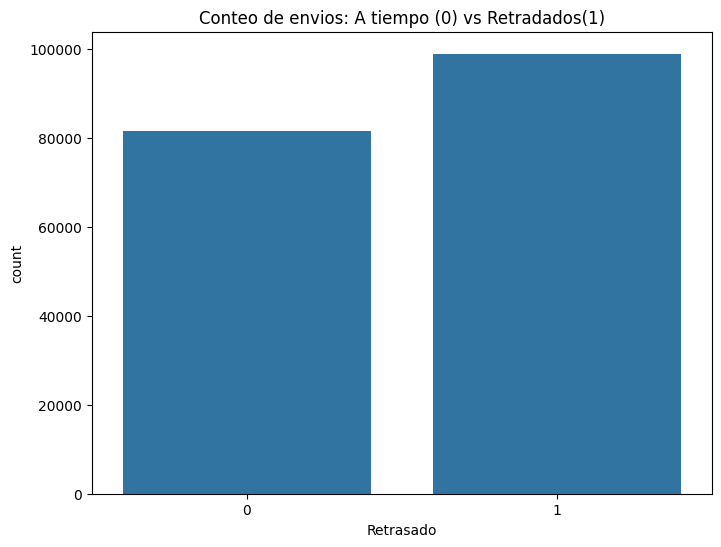

In [ ]:
plt.figure(figsize= (8,6))
sns.countplot(x='Retrasado', data=df_limpio)
plt.title('Conteo de envios: A tiempo (0) vs Retradados(1)')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

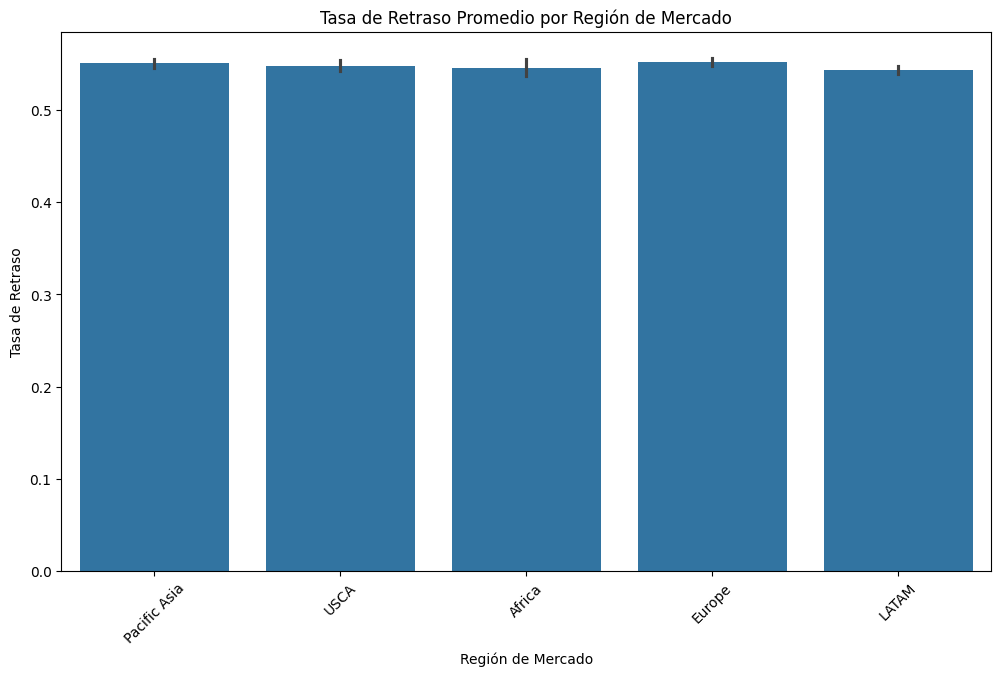

In [ ]:
#¿Qué rutas son las más problemáticas?

plt.figure(figsize=(12,7))
sns.barplot(x='Market',y='Retrasado', data=df_limpio)
plt.title('Tasa de Retraso Promedio por Región de Mercado')
plt.ylabel('Tasa de Retraso')
plt.xlabel('Región de Mercado')
plt.xticks(rotation=45)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

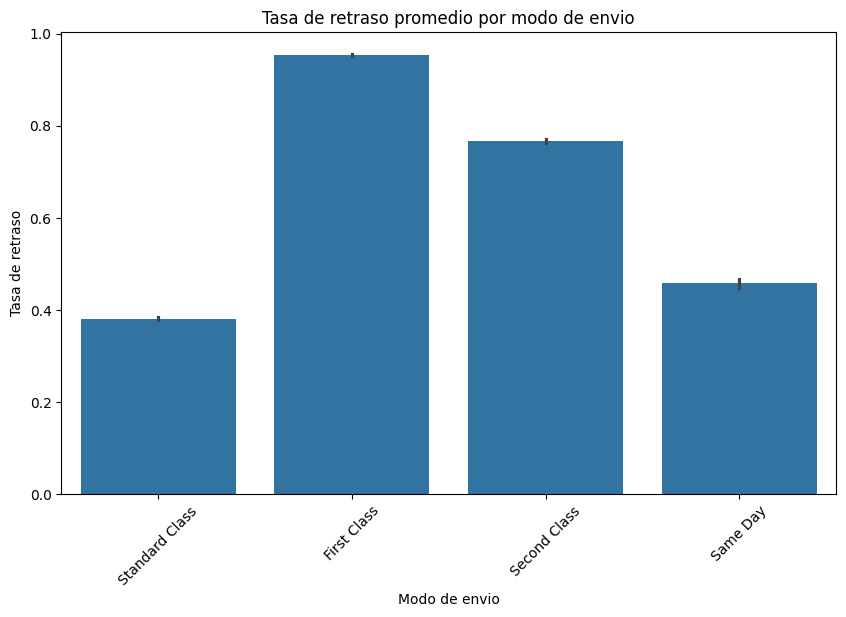

In [ ]:
#El modo de envio ¿Inlfuye?
plt.figure(figsize=(10,6))
sns.barplot(x='Shipping Mode', y='Retrasado',data=df_limpio)
plt.title('Tasa de retraso promedio por modo de envio')
plt.ylabel('Tasa de retraso')
plt.xlabel('Modo de envio')
plt.xticks(rotation=45)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

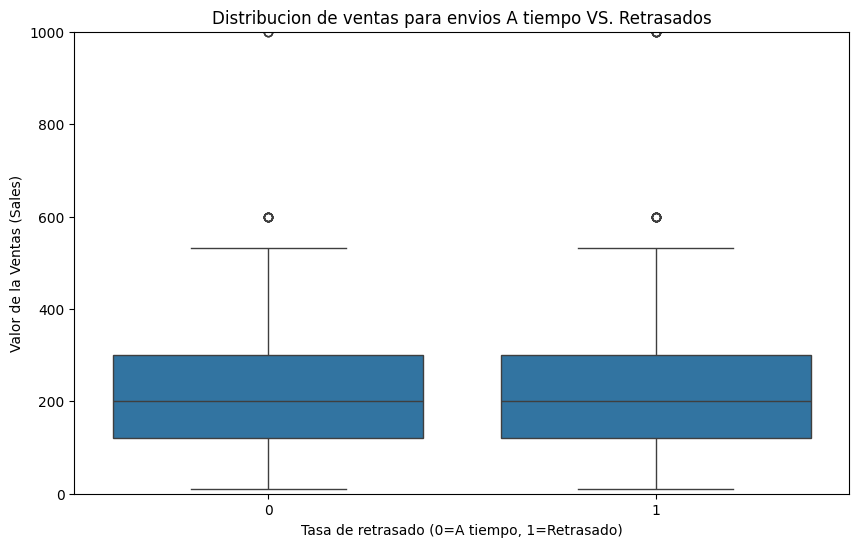

In [ ]:
#El valor de la venta (sales) ¿Influye? ¿Los productos caros retrasan más o menos que los baratos?
plt.figure(figsize=(10,6))
sns.boxplot(x='Retrasado', y='Sales', data=df_limpio)
plt.title('Distribucion de ventas para envios A tiempo VS. Retrasados')
plt.ylabel('Valor de la Ventas (Sales)')
plt.xlabel('Tasa de retrasado (0=A tiempo, 1=Retrasado)')
plt.ylim(0,1000)
plt.show

Comparar las "cajas". Si la caja del '1' (Retrasado) está más arriba o más abajo que la del '0' (A Tiempo), significa que el valor de la venta sí parece influir en los retrasos.

In [ ]:
# --- FASE 2: FEATURE ENGINEERING Y PREPARACIÓN DEL MODELO (VERSIÓN FINAL Y DEFINITIVA) ---
print("Iniciando Feature Engineering...")

#1. Crear la única característica de tiempo que necesitamos y que es 'honesta'
print('Iniciando Feature Engineering final---')
df_limpio['order_day_of_week']=df_limpio['order date (DateOrders)'].dt.dayofweek
df_limpio['order_month']=df_limpio['order date (DateOrders)'].dt.month
print('Características de tiempo "order_day_of_week" y "order_month" creadas')

features_categoricas_finales=['Type','Market','Shipping Mode','Customer Segment','Order Region']

features_numericas_finales=['Sales','order_month','order_day_of_week']

#3. CREAR EL DATAFRAME 'X' FINAL Y 'y'
#Creamos X seleccionando ÚNICAMENTE las columnas honestas desde el df_limpio
X=df_limpio[features_categoricas_finales+features_numericas_finales].copy()
y=df_limpio['Retrasado']

#Manejamos posibles nulos que queden en las columnas seleccionadas
X=X.dropna()
y=y[X.index] #Importante: asegurarnos que 'y' se alinee con 'X' después de borrar filas

print('\nDataFrame final "X" para el modelo creado. Estas son sus columnas: ')
X.info()

#4. Dividiren entrenamiento y prueba

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(f'\n¡Datos 100% honestos listos! Tamaño de X_train:{X_train.shape}')


Iniciando Feature Engineering...
Iniciando Feature Engineering final---
Características de tiempo "order_day_of_week" y "order_month" creadas

DataFrame final "X" para el modelo creado. Estas son sus columnas: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Type               180519 non-null  object 
 1   Market             180519 non-null  object 
 2   Shipping Mode      180519 non-null  object 
 3   Customer Segment   180519 non-null  object 
 4   Order Region       180519 non-null  object 
 5   Sales              180519 non-null  float64
 6   order_month        180519 non-null  int32  
 7   order_day_of_week  180519 non-null  int32  
dtypes: float64(1), int32(2), object(5)
memory usage: 9.6+ MB

¡Datos 100% honestos listos! Tamaño de X_train:(144415, 8)


In [ ]:
#Fase de modelado y evaluacion

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#1.Construir preprocesador. Este objeto aplicará los pasos correctos a cada tipo de columna

preprocesador=ColumnTransformer(transformers=[('num',StandardScaler(),features_numericas_finales),('cat',OneHotEncoder(handle_unknown='ignore'),features_categoricas_finales)],remainder='passthrough')
print('Preprocesador construido exitosamente')

Preprocesador construido exitosamente


In [ ]:
import warnings
#Contendiente 1. Regresión Logística (Baseline)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Import necessary components for preprocesador (if not already in scope from previous cells)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# REDEFINE preprocesador with the correct feature lists
# These variables (features_categoricas_finales, features_numericas_finales) are available from MfiED1r_UcRA
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_numericas_finales), # Use the final numerical features
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_categoricas_finales) # Use the final categorical features
    ],
    remainder='passthrough'
)
print("Preprocesador redefinido con las características correctas para el modelo.")


#Creamos el pipeline completo
pipeline_lr=Pipeline(steps=
 [('preprocesador', preprocesador),
  ('clasificador',LogisticRegression(random_state=42, class_weight='balanced',max_iter=1000))])

#Entrenamos
print("\nEntrenando el modelo de Regresión Logística")

# Temporarily ignore ConvergenceWarning for LogisticRegression if it arises due to max_iter
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pipeline_lr.fit(X_train, y_train)

#Predecimos y evaluamos
print("Evaluando el modelo Baseline de Regresión Logística")
y_pred_lr=pipeline_lr.predict(X_test)

print("\n---Reporte de Clasificacion: Regresion Logistica")
print(classification_report(y_test,y_pred_lr))

Preprocesador redefinido con las características correctas para el modelo.

Entrenando el modelo de Regresión Logística
Evaluando el modelo Baseline de Regresión Logística

---Reporte de Clasificacion: Regresion Logistica
              precision    recall  f1-score   support

           0       0.61      0.88      0.72     16308
           1       0.85      0.54      0.66     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104



In [ ]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf=Pipeline(steps=[('preprocesador',preprocesador),('clasificador',RandomForestClassifier(random_state=42, class_weight='balanced',n_jobs=-1))])

print('\nEntrenando el modelo de Random Forest')
pipeline_rf.fit(X_train, y_train)

# Predecimos con el modelo entrenado
y_pred_rf = pipeline_rf.predict(X_test)

print('\n---Reporte de clasificación:RandomForest--')
print(classification_report(y_test, y_pred_rf))


Entrenando el modelo de Random Forest

---Reporte de clasificación:RandomForest--
              precision    recall  f1-score   support

           0       0.68      0.71      0.69     16308
           1       0.75      0.72      0.74     19796

    accuracy                           0.72     36104
   macro avg       0.71      0.72      0.71     36104
weighted avg       0.72      0.72      0.72     36104



# Análisis Final
1. Regresión Logística (Baseline):
*   f1-score (clase 1 - Retrasado): 0.66
*   precision: 0.85
*   recall: 0.54

Análisis: Este modelo es el "Guardia Preciso". Es muy confiable cuando alerta (acierta el 85% de las veces), pero es demasiado tímido y se le escapan casi la mitad de los problemas (solo encuentra el 54% de los retrasos).


2. RandomForest (Modelo Avanzado):

*   f1-score (clase 1 - Retrasado): 0.74
*   precision: 0.75
*   recall: 0.72

Análisis: ¡Este es nuestro campeón indiscutible! Ha encontrado un equilibrio fantástico.

No solo es razonablemente preciso (acierta el 75% de sus alertas).
Sino que es mucho más "sensible" y logra encontrar al 72% de todos los retrasos reales.
Su F1-score de 0.74 es un resultado excelente y muy sólido para un problema de negocio complejo.

# Conclusión

Después de eliminar toda la información del futuro y forzar a los modelos a aprender de las causas reales, el RandomForestClassifier demostró ser significativamente superior. Se elige como modelo final, ya que ofrece un excelente balance, prediciendo correctamente el 75% de sus alertas de retraso y, lo que es más importante, identificando al 72% de todos los envíos que realmente se retrasan. Este modelo proporciona una base sólida y confiable para un sistema de alerta temprana.

      Caracteristica  Importancia
0              Sales     0.356757
2  order_day_of_week     0.151182
1        order_month     0.136886


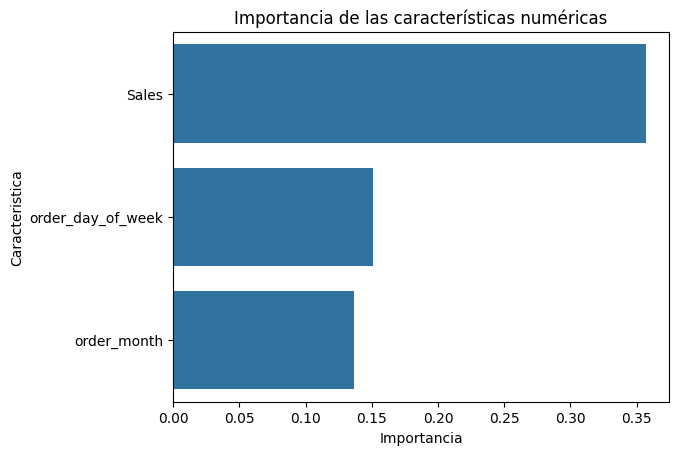

In [ ]:
#Veamos qué hay adentro

#Código para la interpratbilidad

importancias=pipeline_rf.named_steps['clasificador'].feature_importances_

df_importancias_num=pd.DataFrame({'Caracteristica':features_numericas_finales, 'Importancia':importancias[:len(features_numericas_finales)]}).sort_values('Importancia',ascending=False)

print(df_importancias_num)

sns.barplot(x='Importancia', y='Caracteristica', data=df_importancias_num)
plt.title('Importancia de las características numéricas')
plt.savefig('importancia_caracteristicas.png', bbox_inches='tight')
plt.show()

# Análisis de la interpretabilidad

Tras un riguroso proceso de limpieza para eliminar toda la información del futuro (data leakage), el modelo RandomForest final (con un F1-score de 0.74) reveló los verdaderos impulsores de los retrasos en los envíos.

El análisis de importancia de características demuestra que el valor de la venta (Sales) es el factor más determinante, representando más de un tercio del poder predictivo. Le siguen los patrones temporales, como el día de la semana y el mes del pedido.

Esto sugiere que la estrategia para reducir los retrasos no debe ser geográfica, sino que debe enfocarse en optimizar los procesos logísticos diferenciados por el valor de la orden y en mejorar la gestión de la capacidad durante los picos de demanda semanales y mensuales.